# 25 &middot; Modal Muscle Actuation

How does a soft creature *move itself*? Not with an artist painting muscle
fibers, and not with a hand-rigged skeleton &mdash; but with **its own natural
vibration modes**, used as actuators.

This is the idea behind **Modal Muscles** / *Actuators à la Mode*
([Benchekroun et&nbsp;al.](https://www.dgp.toronto.edu/projects/)):

* A reduced **skinning-eigenmode subspace** $B$ carries the deformation, with a
  handful of reduced coordinates $\mathbf{z}$ so that $\mathbf{x} = B\,\mathbf{z}$.
* A small set of **displacement modes** $D$ &mdash; obtained for *free* from a
  linear modal analysis of the shape &mdash; act as **muscles**. Dialing each
  muscle's amplitude $a_i$ drives a **clustered plastic stretch tensor**: a
  per-element rest *target* that the flesh tries to match, while passive ARAP
  elasticity and inertia resist.
* No painted muscles, no user rig, no training data. The actuation space *is* the
  shape's own modal space.

We will:

1. Build a 2D **caterpillar** creature (four legs, fully triangulated).
2. Ask *how does it naturally move?* &rarr; linear modal analysis, dropping the
   rigid modes.
3. Treat those modes as muscles and **float** the creature in gravity-free space,
   contrasting the kinematic actuation target (left) against the inertial
   simulation (right), and plotting how the modes evolve in time.
4. Drop it under **gravity with contact** and wiggle its muscles into a **gait**,
   tracking the center of mass as it crawls.

The whole modal-muscle solver lives in one standardized simulator class,
`ModalMuscle`, built from **flat simkit functions**. The interactive counterpart
is `examples/interactive_demos/014_modal_muscles.py`.

In [1]:
%matplotlib inline
import numpy as np
import scipy as sp
import scipy.sparse as sps
import matplotlib.pyplot as plt
from matplotlib import animation

import simkit as sk
from simkit.clustered_plastic_stretch_tensor import clustered_plastic_stretch_tensor
from simkit.fast_sandwich_transform_clustered import fast_sandwich_transform_clustered
from simkit.solvers import block_coord
import utils

# sparse @ on some scipy/numpy combos emits spurious 'divide by zero in matmul'
# warnings; the arithmetic is exact. Silence them for a clean notebook.
import warnings; warnings.filterwarnings("ignore")
np.seterr(all="ignore")

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

## A creature, not a rectangle

We build a little **caterpillar**: a horizontal body bar with four stubby legs.
Rather than load a mesh from disk, we triangulate it from scratch &mdash; lay a
regular triangle grid over a bounding box and keep only the triangles whose
centroid falls inside the body bar or one of the four legs. Dropping the unused
vertices leaves a single watertight, conforming triangle mesh.

1719 vertices, 3058 triangles


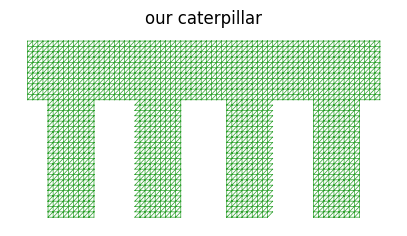

In [2]:
def caterpillar_mesh(nx=70, ny=34, W=4.0, H=2.0,
                     body_frac=0.34, n_legs=4, leg_frac=0.5):
    # A staple-/caterpillar-shaped triangle mesh: a body bar + n_legs legs.
    # body_frac: fraction of the height taken by the top bar.
    # leg_frac:  total fraction of the width occupied by the legs.
    xs = np.linspace(0, W, nx); ys = np.linspace(0, H, ny)
    XX, YY = np.meshgrid(xs, ys, indexing="xy")
    X = np.stack([XX.ravel(), YY.ravel()], axis=1)
    i, j = np.meshgrid(np.arange(nx - 1), np.arange(ny - 1), indexing="xy")
    v00 = (j*nx + i).ravel();     v01 = (j*nx + i + 1).ravel()
    v10 = ((j+1)*nx + i).ravel(); v11 = ((j+1)*nx + i + 1).ravel()
    T = np.stack([np.stack([v00, v01, v11], 1),
                  np.stack([v00, v11, v10], 1)], 1).reshape(-1, 3)

    c = X[T].mean(1)                       # triangle centroids
    body_y0 = H * (1 - body_frac)
    in_body = c[:, 1] >= body_y0           # the top bar
    leg_w = W * leg_frac / n_legs
    span = W / n_legs
    in_leg = np.zeros(len(c), bool)
    for k in range(n_legs):                # four legs hanging below the bar
        cx = span * (k + 0.5)
        in_leg |= (np.abs(c[:, 0] - cx) <= leg_w / 2) & (c[:, 1] < body_y0)

    Tk = T[in_body | in_leg]
    used = np.unique(Tk)                   # drop vertices no triangle references
    remap = -np.ones(X.shape[0], int); remap[used] = np.arange(len(used))
    return X[used], remap[Tk]

X, T = caterpillar_mesh()
X = sk.normalize_and_center(X)             # center at origin, unit-ish scale
n, dim = X.shape
print(f"{n} vertices, {T.shape[0]} triangles")

fig, ax = plt.subplots(figsize=(5, 2.6))
ax.triplot(X[:, 0], X[:, 1], T, color="C2", lw=0.5)
ax.set_aspect("equal"); ax.set_title("our caterpillar"); ax.axis("off")
plt.show()

## How does this shape *naturally* move?

Pluck the creature and let it ring. The motions it settles into are its
**natural vibration modes** &mdash; the eigenvectors of the generalized
eigenproblem $K\,\mathbf{d} = \lambda\, M\,\mathbf{d}$, where $K$ is the elastic
stiffness and $M$ is the mass matrix. `sk.linear_modal_analysis` returns them
ordered by eigenvalue (frequency²).

The lowest few eigenvalues are essentially **zero**: those are the *rigid modes*
&mdash; ways the shape can move without deforming at all. In 2D there are exactly
**three** (two translations + one rotation). They carry no elastic energy, so
they make useless muscles; we drop them and keep the first genuine
**deformation** modes that follow.

In [3]:
n_keep = 4                                   # how many real deformation modes we want
n_rigid = 3                                  # 2 translations + 1 rotation (2D)
E, D = sk.linear_modal_analysis(X, T, n_rigid + n_keep)
modeset = list(range(n_rigid, n_rigid + n_keep))   # [3, 4, 5, 6]

print("eigenvalues (frequency^2):")
for i, e in enumerate(E):
    tag = "  <- rigid (approx 0)" if i < n_rigid else "  <- muscle mode"
    print(f"  mode {i}:  {e: .4e}{tag}")

eigenvalues (frequency^2):
  mode 0:  -3.6066e-13  <- rigid (approx 0)
  mode 1:  -7.2885e-14  <- rigid (approx 0)
  mode 2:   3.3790e-13  <- rigid (approx 0)
  mode 3:   1.2494e-01  <- muscle mode
  mode 4:   3.0425e-01  <- muscle mode
  mode 5:   3.7463e-01  <- muscle mode
  mode 6:   8.5344e-01  <- muscle mode


### The first four muscle modes

Each surviving mode is a whole-body deformation field. Below we visualize them by
pushing the rest shape along each mode. These four fields are our entire
**muscle vocabulary** &mdash; obtained automatically, with no rig and no painted
fibers.

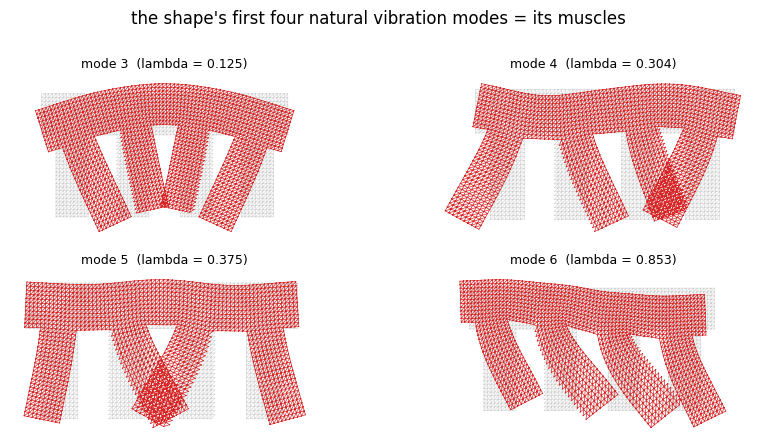

In [4]:
# a per-mode visual amplitude so each mode displaces a comparable, visible amount
scale = 0.35 / np.abs(D[:, modeset]).max(0)

fig, axes = plt.subplots(2, 2, figsize=(9, 4.4))
for ax, mi, sc in zip(axes.ravel(), modeset, scale):
    dvec = D[:, mi].reshape(n, dim)
    ax.triplot(X[:, 0], X[:, 1], T, color="0.82", lw=0.4)          # rest
    Xp = X + sc * dvec
    ax.triplot(Xp[:, 0], Xp[:, 1], T, color="C3", lw=0.5)          # actuated
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(f"mode {mi}  (lambda = {E[mi]:.3f})", fontsize=9)
fig.suptitle("the shape's first four natural vibration modes = its muscles", y=1.0)
fig.tight_layout(); plt.show()

## Modal muscles, in one paragraph

We keep two reduced spaces over the same mesh:

* **Subspace $B$** &mdash; *skinning eigenmodes* (`sk.skinning_eigenmodes`),
  mass-orthonormalized. The simulation only ever solves for the reduced state
  $\mathbf{z}$, with $\mathbf{x} = B\,\mathbf{z}$. This is what makes it fast.
* **Muscles $D$** &mdash; the linear modes we just found, plus the rest pose as a
  final column so the activation vector $\mathbf{a}$ can encode "stay at rest".
  Activating $\mathbf{a}$ defines, per element, a target **plastic stretch** the
  material wants to assume.

Each timestep alternates two cheap steps (`simkit.solvers.block_coord`):

* **local step** &mdash; per *cluster* of elements, a `polar_svd` gives the
  best-fit rotation for the **passive** ARAP energy *and* for the **active**
  clustered plastic-stretch target $K(\mathbf{z}, \mathbf{a})$.
* **global step** &mdash; one Cholesky back-solve in the subspace $B$ that
  balances passive elasticity, the active muscle pull, inertia, and (later)
  contact.

The next cell is the whole solver, packed into a single standardized simulator
class, `ModalMuscle`. Its `__init__` runs all the precompute once (subspace
operators, muscle operators, clusters, reduced mass, the Cholesky factorization,
optional contact operators, and the constant gravity force $b_0$); from then on we
only call `rest_state()` and `step(z, z_dot, a)`. The `local_step` / `global_step`
pieces are kept as named methods so you can read the passive (ARAP) and active
(muscle) energy contributions where they enter the global solve.

In [5]:
class ModalMuscle:
    """Reduced modal-muscle dynamics: x = B z, muscles drive a clustered plastic
    stretch target while passive ARAP elasticity + inertia (+ optional contact)
    resist. One local/global block_coord solve per step, all inside subspace B."""

    def __init__(self, X, T, B, D, l, d, *, mu=1e6, gamma=1e6, rho=1e3, h=1e-2,
                 b0=None, contact=False, cI=None, plane_pos=None,
                 alpha=1.0, max_iter=10, tolerance=1e-6):
        # B : (dim*n, r) skinning-eigenmode subspace; reduced state z, x = B z.
        # D : (dim*n, m) muscle (displacement) modes; activation a (m,1).
        # l : passive cubature cluster labels;  d : active cluster labels.
        # mu, gamma : passive / active stiffness;  b0 : constant reduced force.
        dim, nT = X.shape[1], T.shape[0]
        l = l.astype(int); d = d.astype(int)
        self.dim, self.h, self.alpha = dim, h, alpha
        self.max_iter, self.tolerance = max_iter, tolerance
        self.B, self.D, self.contact = B, D, contact

        vol = sk.volume(X, T)
        J = sk.deformation_jacobian(X, T)
        Mv = sps.kron(sk.massmatrix(X, T, rho=rho), sps.identity(dim))
        self.Mv = Mv

        # ---- passive ARAP, grouped into clusters ----
        mu_v, gamma_v = np.full((nT, 1), mu), np.full((nT, 1), gamma)
        P, _ = sk.cluster_grouping_matrices(l, X, T)
        A = sps.diags(vol.flatten())
        AMue  = sps.kron(A @ sps.diags(mu_v.flatten()),       sps.identity(dim * dim))
        PAMue = sps.kron(P @ (A @ sps.diags(mu_v.flatten())), sps.identity(dim * dim))
        self.AMuPJB = (PAMue @ J) @ B
        L_passive = J.T @ AMue @ J

        # ---- active muscle force (clustered plastic stretch tensor) ----
        AGammae = sps.kron(A @ sps.diags(gamma_v.flatten()), sps.identity(dim * dim))
        L_active = J.T @ AGammae @ J
        BJAgamma = B.T @ (J.T @ AGammae)
        self.K   = clustered_plastic_stretch_tensor(X, T, d, B, D, w=(vol * gamma_v).reshape(-1, 1))
        self.fst = fast_sandwich_transform_clustered(BJAgamma, J @ D, d, dim=dim)

        # ---- reduced mass, stiffness operators, projection bases ----
        self.BMB = B.T @ Mv @ B
        self.BMy = B.T @ Mv @ X.reshape(-1, 1)
        self.DMD = D.T @ Mv @ D
        self.DMy = D.T @ Mv @ X.reshape(-1, 1)

        # ---- system Hessian + Cholesky factorization ----
        H = B.T @ L_passive @ B + B.T @ L_active @ B + self.BMB / h**2
        self.chol_H = sp.linalg.cho_factor(H)
        self.b = np.zeros((B.shape[1], 1)) if b0 is None else b0.reshape(-1, 1)

        self.num_passive_clusters = int(l.max()) + 1
        self.num_active_clusters  = int(d.max()) + 1

        # ---- optional ground-plane contact ----
        if contact:
            if plane_pos is None:
                plane_pos = np.zeros((dim, 1))
            Se = sps.kron(sk.selection_matrix(np.unique(cI), X.shape[0]), sps.identity(dim))
            self.plane_pos = plane_pos
            self.Je = Se @ B
            self.JeQi = sp.linalg.cho_solve(self.chol_H, self.Je.T).T

    def rest_state(self, X):
        # Reduced rest state (z, z_dot, a) projected from the rest pose X.
        z = sk.project_into_subspace(X.reshape(-1, 1), self.B, M=self.Mv, BMB=self.BMB, BMy=self.BMy)
        a = sk.project_into_subspace(X.reshape(-1, 1), self.D, M=self.Mv, BMB=self.DMD, BMy=self.DMy)
        return z, np.zeros_like(z), a

    def _contact_projection(self, z, f, z_curr):
        # Velocity-level ground-plane contact, in the spirit of projective
        # dynamics, folded into the global solve: any contact point below the
        # plane AND moving into it gets its downward velocity removed.
        dim, h, alpha = self.dim, self.h, self.alpha
        Je, JeQi, plane_pos = self.Je, self.JeQi, self.plane_pos
        z_dot_tent = (sp.linalg.cho_solve(self.chol_H, f) - z_curr) / h
        Pp = (Je @ z).reshape(-1, dim)
        under = (Pp[:, 1] < plane_pos[1]).flatten()
        local_vel = (Je @ z_dot_tent).reshape(-1, dim)
        ci = np.where(under & (local_vel[:, 1] < 0))[0]
        if ci.shape[0] == 0:
            return np.zeros_like(f)
        idx = (np.repeat(ci[:, None], dim, 1) * dim + np.arange(dim)).flatten()
        JeI, L = Je[idx, :], JeQi[idx, :]
        v = np.zeros((ci.shape[0], dim)); v[:, 0] = (1.0 - alpha) * local_vel[ci, 0]
        p = (JeI @ z_curr).reshape(-1, dim)
        bb = (v * h + p - (L @ f).reshape(-1, dim)).reshape(-1, 1)
        if L.shape[0] >= L.shape[1]:
            return np.linalg.solve(L.T @ L, L.T @ bb)
        return L.T @ np.linalg.solve(L @ L.T, bb)

    def local_step(self, zc, a):
        # best-fit rotations: passive ARAP + active clustered plastic stretch
        R_p = sk.polar_svd((self.AMuPJB @ zc).reshape(-1, self.dim, self.dim))[0]
        R_a = sk.polar_svd(self.K(zc, a))[0]
        return np.vstack([R_p.reshape(-1, 1), R_a.reshape(-1, 1)])

    def global_step(self, zc, r, a, k, z_curr):
        # one Cholesky solve in the subspace, summing the reduced forces
        dim = self.dim
        pd = self.num_passive_clusters * dim**2
        ad = self.num_active_clusters * dim**2
        E_inertia = k                                          # inertial target
        E_passive = self.AMuPJB.T @ r[:pd]                    # passive ARAP pull
        E_active  = self.fst(r[pd:pd + ad].reshape(-1, dim, dim)) @ a  # muscle pull
        f = E_inertia + E_passive + E_active - self.b
        if self.contact:
            contact = self._contact_projection(zc, f, z_curr)  # ground-plane push
            f = f + contact
        return sp.linalg.cho_solve(self.chol_H, f)

    def step(self, z, z_dot, a):
        # Advance one timestep; return the next reduced state z_next.
        h = self.h
        k = self.BMB @ (z + h * z_dot) / h**2                 # inertial target
        z_curr = z.copy()
        local  = lambda zc: self.local_step(zc, a)
        glob   = lambda zc, r: self.global_step(zc, r, a, k, z_curr)
        return block_coord(z.copy(), glob, local,
                           tolerance=self.tolerance, max_iter=self.max_iter)

## Building the reduced model

We assemble the three reduced ingredients once:

* **`B`** &mdash; the skinning-eigenmode subspace, mass-orthonormalized.
* **`Dms`** &mdash; our four muscle modes, with the rest pose appended as a final
  column (so the activation can hold the rest state).
* **`l`** &mdash; *spectral cubature* cluster labels, grouping the triangles into
  a handful of clusters so the local step is cheap.

`limit_a` is a per-mode amplitude ceiling from
`sk.limit_actuation_dirichlet_energy`: how hard we can pull a muscle before the
plastic target becomes unreasonably stretched. We scale all our sinusoids by
it.

In [6]:
num_modes  = 8     # skinning-eigenmode subspace dimension
num_clust  = 20    # cubature clusters for the passive local step

Wmd, _E, B = sk.skinning_eigenmodes(X, T, num_modes)
B = sk.orthonormalize(B, M=sps.kron(sk.massmatrix(X, T), sps.identity(dim)))

# muscles = the 4 deformation modes + rest pose (so activation can encode "rest")
Dms = np.hstack([D[:, modeset], X.reshape(-1, 1)])

# cubature: group triangles into clusters for the clustered local/global steps
_cI, _cW, l = sk.spectral_cubature(X, T, Wmd, num_clust, return_labels=True)
d = np.zeros(T.shape[0])                       # a single active cluster

limit_a = sk.limit_actuation_dirichlet_energy(X, T, D, max_s=2.0)[modeset]
print(f"subspace dim = {B.shape[1]},  muscles = {len(modeset)},  clusters = {num_clust}")
print("per-muscle amplitude ceiling:", np.round(limit_a, 3))

subspace dim = 48,  muscles = 4,  clusters = 20
per-muscle amplitude ceiling: [0.48  0.394 0.298 0.248]


## Floating in space: actuation target vs. inertial response

First, no gravity and no ground &mdash; the creature **floats** in 2D, driven
only by its muscles and its own inertia. We wiggle the first two muscles
sinusoidally.

To *see* what the simulation is doing, we show two things side by side:

* **left (the actuation target):** the purely kinematic shape the muscles ask
  for,

  $$
  \mathbf{x}_{\text{target}} = \mathbf{x}_{\text{rest}} + \sum_i a_i(t)\,D_i .
  $$

  This is the muscle command &mdash; instantaneous and weightless.
* **right (the simulation):** the actual reduced dynamics $\mathbf{x} = B\,\mathbf{z}$,
  where inertia and passive elasticity *lag and smooth* that command.

A floating body conserves momentum, so it can change its *shape* freely but its
center of mass barely moves &mdash; the muscles let it "swim in place".

In [7]:
# --- a gravity-free, contact-free modal-muscle sim ---
sim_float = ModalMuscle(X, T, B, Dms, l, d,
                        mu=1e5, gamma=1e5, rho=1e3, h=0.02, max_iter=10)
h = sim_float.h
n_steps = 180

# sinusoidal muscle command: amplitude (x limit_a), period (s), phase (x period)
amp_float    = np.array([0.9, 0.6, 0.0, 0.0]) * limit_a
period_float = np.array([1.0, 0.7, 1.0, 1.0])
phase_float  = np.array([0.0, 0.25, 0.0, 0.0])

def activation_float(t):
    return amp_float * np.sin(2 * np.pi * (t / period_float + phase_float))

# operators to read off the realized modal amplitude of the *simulation*
Dm   = D[:, modeset]
DmM  = Dm.T @ sim_float.Mv                        # (4, dim*n)
DmMD = np.diag(Dm.T @ sim_float.Mv @ Dm)         # (4,)
xrest = X.reshape(-1, 1)

z, z_dot, a = sim_float.rest_state(X)
sim_frames, tgt_frames, a_input, a_realized = [], [], [], []
for i in range(n_steps):
    t = i * h
    a_t = activation_float(t)
    a[:-1, 0] = a_t                               # last entry holds the rest column
    z_next = sim_float.step(z, z_dot, a)
    z_dot = (z_next - z) / h
    z = z_next.copy()

    x_sim = (B @ z)                               # simulated positions
    sim_frames.append(x_sim.reshape(n, dim))
    tgt_frames.append((xrest + Dm @ a_t.reshape(-1, 1)).reshape(n, dim))
    a_input.append(a_t)
    a_realized.append(((DmM @ (x_sim - xrest)).flatten() / DmMD))

a_input    = np.array(a_input)
a_realized = np.array(a_realized)
print("floated", n_steps, "steps")

floated 180 steps


### Side by side: command (left) vs. simulation (right)

In [8]:
allpts = np.concatenate(sim_frames + tgt_frames, 0)
lo = allpts.min(0) - 0.15; hi = allpts.max(0) + 0.15

fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 3.2))
def draw_float(fi):
    for ax, frames, title, col in [(axL, tgt_frames, "actuation target  x = X + sum a_i D_i", "C3"),
                                   (axR, sim_frames, "simulation  x = B z", "C0")]:
        ax.clear()
        ax.triplot(frames[fi][:, 0], frames[fi][:, 1], T, color=col, lw=0.5)
        ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[1], hi[1])
        ax.set_aspect("equal"); ax.axis("off"); ax.set_title(title, fontsize=10)
    return []

anim = animation.FuncAnimation(fig, draw_float, frames=range(0, n_steps, 3),
                               interval=60, blit=False)
utils.show_video(fig, anim, "media/25_floating.mp4", fps=24)

### How the modes evolve through time

The muscle **command** is a clean sinusoid (dashed). The body's **realized**
modal amplitude (solid) &mdash; the projection of the actual simulated motion
onto each linear mode &mdash; lags and rounds it off: that is inertia and passive
stiffness filtering the command. Undriven modes (2 and 3) stay near zero, but
pick up a little energy through nonlinear coupling.

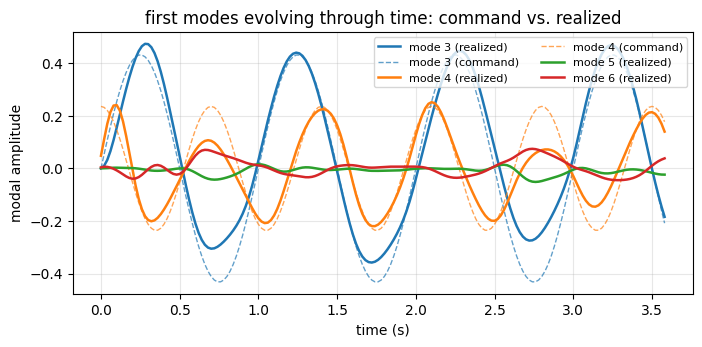

In [9]:
fig, ax = plt.subplots(figsize=(8, 3.4))
ts = np.arange(n_steps) * h
colors = ["C0", "C1", "C2", "C3"]
for j, mi in enumerate(modeset):
    ax.plot(ts, a_realized[:, j], color=colors[j], lw=1.8, label=f"mode {mi} (realized)")
    if amp_float[j] != 0:
        ax.plot(ts, a_input[:, j], color=colors[j], lw=1.0, ls="--", alpha=0.7,
                label=f"mode {mi} (command)")
ax.set_xlabel("time (s)"); ax.set_ylabel("modal amplitude")
ax.set_title("first modes evolving through time: command vs. realized")
ax.legend(fontsize=8, ncol=2, loc="upper right"); ax.grid(alpha=0.3)
plt.show()

## Now let it fall, and let it crawl

Time to put the caterpillar on the ground. We rebuild the sim with two additions:

* **gravity** &mdash; a constant reduced force $-B^\top \mathbf{g}$.
* **contact** &mdash; a velocity-level ground plane, in the spirit of
  *projective dynamics*: at each global solve, every boundary contact point that
  is below the plane and moving into it has its into-the-ground velocity removed
  (`_contact_projection`). Tangential sliding is preserved, so pushing legs
  against the floor produces forward thrust.

Contact points are a handful of **boundary vertices** (found by keeping mesh
edges that belong to a single triangle, then farthest-point sampling). We place
the floor just below the creature so it drops, lands, and then crawls under
muscle power.

In [10]:
def boundary_vertices(T):
    # vertices on edges that belong to exactly one triangle
    e = np.sort(np.vstack([T[:, [0, 1]], T[:, [1, 2]], T[:, [2, 0]]]), axis=1)
    uniq, cnt = np.unique(e, axis=0, return_counts=True)
    return np.unique(uniq[cnt == 1])

bv = boundary_vertices(T)
cI = bv[sk.farthest_point_sampling(X[bv, :], 30)]    # contact sample points
ground_y = float(X[:, 1].min()) - 0.15               # floor just below the feet

g = B.T @ sk.gravity_force(X, T, a=-9.8, rho=1e3).reshape(-1, 1)
sim_grav = ModalMuscle(X, T, B, Dms, l, d,
                       mu=1e6, gamma=1e6, rho=1e3, h=1e-2,
                       b0=-g, contact=True, cI=cI,
                       plane_pos=np.array([[0.0], [ground_y]]), alpha=1.0,
                       max_iter=10)
print(f"{cI.shape[0]} contact points,  ground at y = {ground_y:.3f}")

30 contact points,  ground at y = -0.720


### Dial in a gait

These four lines are the knobs &mdash; **edit them** and re-run to invent new
gaits. Each muscle gets an amplitude (as a fraction of its ceiling), a period
(seconds), and a phase (fraction of a period). Phase offsets between the legs are
what break symmetry and turn a wiggle into directed crawling.

In [11]:
# ----------------------- EDIT ME: the gait -----------------------
amp_frac = np.array([0.45, 0.35, 0.25, 0.15])   # per-muscle amplitude (x ceiling)
periods  = np.array([1.20, 0.80, 1.00, 0.60])   # seconds per cycle
phases   = np.array([0.00, 0.25, 0.50, 0.10])   # fraction of a period
# -----------------------------------------------------------------
n_steps_g = 450
hg = sim_grav.h
amp_g = amp_frac * limit_a

def activation_gait(t):
    return amp_g * np.sin(2 * np.pi * (t / periods + phases))

# cached center-of-mass operator (subspace COM): com(t) = subspace_com(z_t, ...)
_com0, SB = sk.subspace_com(np.zeros(B.shape[1]), B, X, T, return_SB=True)

z, z_dot, a = sim_grav.rest_state(X)
crawl_frames, com = [], []
for i in range(n_steps_g):
    t = i * hg
    a[:-1, 0] = activation_gait(t)
    z_next = sim_grav.step(z, z_dot, a)
    z_dot = (z_next - z) / hg
    z = z_next.copy()
    crawl_frames.append((B @ z).reshape(n, dim))
    com.append(sk.subspace_com(z.flatten(), B, X, T, SB=SB).flatten())

com = np.array(com)
print(f"crawled {n_steps_g} steps")
print(f"horizontal COM travel: {com[-1, 0] - com[0, 0]:+.3f}")
print(f"vertical COM range:    [{com[:,1].min():.3f}, {com[:,1].max():.3f}]  (ground y = {ground_y:.3f})")

crawled 450 steps
horizontal COM travel: -4.438
vertical COM range:    [-0.130, 0.244]  (ground y = -0.720)


### Center of mass over time

The **subspace center of mass** `sk.subspace_com(z, B, X, T)` reads the creature's
COM straight from the reduced state. Its horizontal coordinate is our measure of
locomotion: a gait that crawls shows steady horizontal drift, with a gentle
vertical bob as the legs cycle.

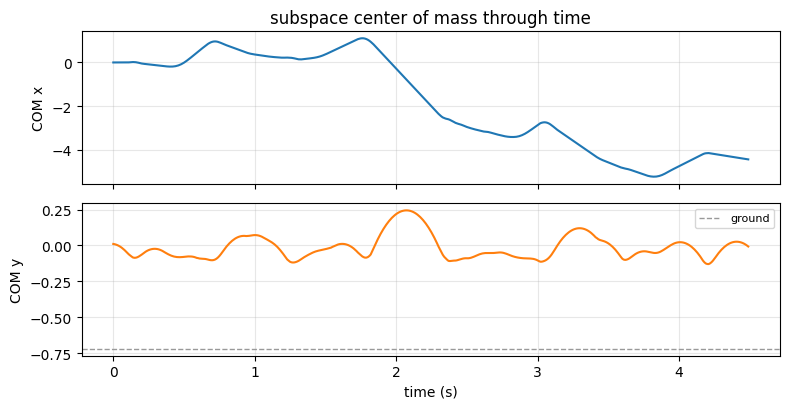

In [12]:
ts_g = np.arange(n_steps_g) * hg
fig, (a1, a2) = plt.subplots(2, 1, figsize=(8, 4.2), sharex=True)
a1.plot(ts_g, com[:, 0], "C0"); a1.set_ylabel("COM x"); a1.grid(alpha=0.3)
a1.set_title("subspace center of mass through time")
a2.plot(ts_g, com[:, 1], "C1"); a2.axhline(ground_y, color="0.6", ls="--", lw=1, label="ground")
a2.set_ylabel("COM y"); a2.set_xlabel("time (s)"); a2.legend(fontsize=8); a2.grid(alpha=0.3)
fig.tight_layout(); plt.show()

### Watch it crawl

Left: the caterpillar over the floor (the COM marked with a dot). Right: its
horizontal COM position drawn in as time advances &mdash; the animated trace of
locomotion.

In [13]:
allc = np.concatenate(crawl_frames, 0)
xlo, xhi = allc[:, 0].min() - 0.3, allc[:, 0].max() + 0.3
ylo, yhi = ground_y - 0.1, allc[:, 1].max() + 0.2
stride = 5
sel = range(0, n_steps_g, stride)

fig, (axA, axB) = plt.subplots(1, 2, figsize=(11, 3.4))
def draw_crawl(fi):
    axA.clear()
    axA.fill_between([xlo, xhi], ylo, ground_y, color="0.85")        # the ground
    axA.axhline(ground_y, color="0.5", lw=1)
    axA.triplot(crawl_frames[fi][:, 0], crawl_frames[fi][:, 1], T, color="C2", lw=0.5)
    axA.plot(com[fi, 0], com[fi, 1], "o", color="C3", ms=6)          # COM marker
    axA.set_xlim(xlo, xhi); axA.set_ylim(ylo, yhi); axA.set_aspect("equal")
    axA.set_title(f"crawling under gravity   t = {fi*hg:.2f}s", fontsize=10); axA.axis("off")

    axB.clear()
    axB.plot(ts_g[:fi+1], com[:fi+1, 0], "C0")
    axB.plot(ts_g[fi], com[fi, 0], "o", color="C3", ms=6)
    axB.set_xlim(0, ts_g[-1]); axB.set_ylim(com[:, 0].min() - 0.1, com[:, 0].max() + 0.1)
    axB.set_xlabel("time (s)"); axB.set_ylabel("COM x")
    axB.set_title("horizontal COM position", fontsize=10); axB.grid(alpha=0.3)
    return []

anim = animation.FuncAnimation(fig, draw_crawl, frames=sel, interval=60, blit=False)
utils.show_video(fig, anim, "media/25_crawling.mp4", fps=24)

## Takeaways

* A shape's **linear vibration modes** (minus the rigid ones) are a ready-made,
  rig-free set of **muscles** &mdash; no painting, no skeleton, no data.
* **Modal muscles** activate those modes as a **clustered plastic stretch**
  target; passive ARAP elasticity and inertia respond, and the whole step is a
  cheap local/global `block_coord` solve **inside a skinning-eigenmode subspace**.
* Floating, the muscles reshape the body while momentum pins the COM. On the
  ground, the same sinusoids &mdash; with **phase offsets between the legs**
  &mdash; turn into a **gait**, and `sk.subspace_com` lets us read locomotion
  straight from the reduced state.
* The whole solver is one standardized `ModalMuscle` class built from **flat
  simkit functions**: `linear_modal_analysis`, `skinning_eigenmodes`,
  `spectral_cubature`, `clustered_plastic_stretch_tensor`,
  `fast_sandwich_transform_clustered`, and `solvers.block_coord`.

Go back to the gait cell and try your own amplitudes, periods, and phases &mdash;
or open `examples/interactive_demos/014_modal_muscles.py` for a live,
slider-driven version, and `examples/modal_muscles/actuators_a_la_mode_2D.py` to
see CMA-ES *optimize* these very parameters for fastest forward crawl.

In [14]:
# Optional: CMA-ES gait optimization (matches actuators_a_la_mode_2D.py).
# Guarded off by default so the notebook never launches a long optimization at
# build time. Flip RUN_CMA = True (and `pip install cma`) to search for the gait
# that maximizes forward COM travel; the budget here is deliberately tiny.
RUN_CMA = False

if RUN_CMA:
    import cma

    def crawl_distance(params):
        amp_f  = np.clip(params[0:4], 0.0, 1.0)
        per    = np.clip(params[4:8], 0.4, 1.5)
        pha    = params[8:12]
        amp_p  = amp_f * limit_a

        z, z_dot, a = sim_grav.rest_state(X)
        for i in range(150):                       # short rollout for the search
            t = i * hg
            a[:-1, 0] = amp_p * np.sin(2 * np.pi * (t / per + pha))
            z_next = sim_grav.step(z, z_dot, a)
            z_dot = (z_next - z) / hg
            z = z_next.copy()
        com_end = sk.subspace_com(z.flatten(), B, X, T, SB=SB).flatten()
        return -(com_end[0] - _com0[0])            # CMA minimizes; we want +x travel

    x0 = np.concatenate([amp_frac, periods, phases])
    es = cma.CMAEvolutionStrategy(x0, 0.2,
                                  {"maxfevals": 24, "popsize": 6, "verbose": -9})
    es.optimize(crawl_distance)
    print("best gait params:", np.round(es.result.xbest, 3))
    print("best forward travel:", round(-es.result.fbest, 4))
else:
    print("CMA-ES disabled (set RUN_CMA = True to optimize the gait).")

CMA-ES disabled (set RUN_CMA = True to optimize the gait).
